IMPORT LIBRARY

In [5]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [9]:
conn = sqlite3.connect("sales_data.db")
cursor= conn.cursor()

CREATING A TABLE 

In [1]:
import sqlite3
conn = sqlite3.connect("sales_data.db")
cursor= conn.cursor()
cursor.execute("""
CREATE TABLE IF NOT EXISTS CUSTOMER
(id INTEGER PRIMARY KEY AUTOINCREMENT,
name TEXT,
age INT,
city TEXT,
TOTAL_SPEED_REAL
)
""")
conn.commit()

In [15]:
customer = [
("adarsh", 53,"mumbai",550),
("aarav", 24,"banaras",530),
("arvind", 33,"ahmdabad",800),
("amey", 22,"allahabd",700),
("shivam", 43,"gujrat",600),
("bhavin", 33,"mumbai",400)
]
cursor.executemany("INSERT INTO customer(name,age,city,total_speed_real) values(?,?,?,?)",customer)
conn.commit()

SQL QUERY RUN IN PYTHON 

In [19]:
import pandas as pd
query="select * from customer"
df=pd.read_sql(query, conn)
df.head()

,id,name,age,city,TOTAL_SPEED_REAL
0,1,adarsh,53,mumbai,550
1,2,aarav,24,banaras,530
2,3,arvind,33,ahmdabad,800
3,4,amey,22,allahabd,700
4,5,shivam,43,gujrat,600


In [7]:
import sqlite3
conn = sqlite3.connect("sales_data.db")
import pandas as pd
query="select * from customer where age <50"
df=pd.read_sql(query, conn)
df.head()

,id,name,age,city,TOTAL_SPEED_REAL
0,2,aarav,24,banaras,530
1,3,arvind,33,ahmdabad,800
2,4,amey,22,allahabd,700
3,5,shivam,43,gujrat,600
4,6,bhavin,33,mumbai,400


In [9]:
query="select avg(age) from customer"
df=pd.read_sql(query, conn)
df.head()

,avg(age)
0,34.666667


DATA VISUALISATION

C:\Users\User\AppData\Local\Temp\ipykernel_5588\1680786651.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="city",y="total_speed_real",data=df,palette="coolwarm")


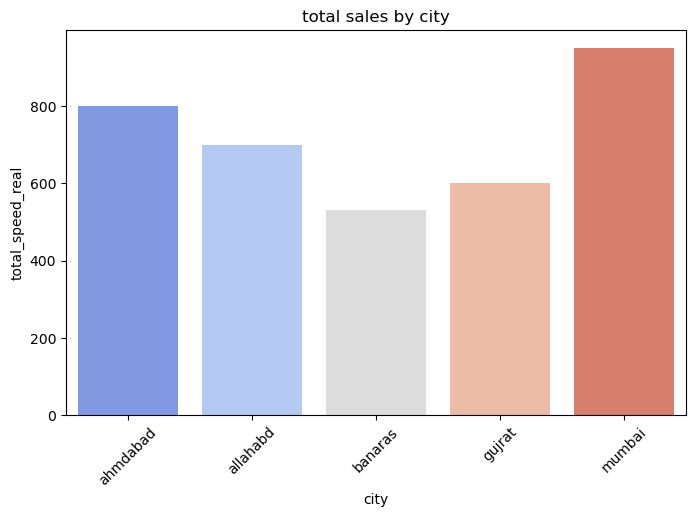

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
query="select city,sum(total_speed_real) AS total_speed_real from customer group by city"
df=pd.read_sql(query,conn)
df.head()

plt.figure(figsize=(8,5))
sns.barplot(x="city",y="total_speed_real",data=df,palette="coolwarm")
plt.xticks(rotation=45)
plt.title("total sales by city")
plt.show()

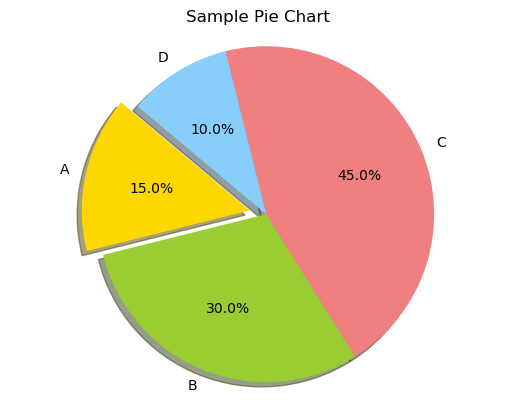

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
query="select city,sum(total_speed_real) AS total_speed_real from customer group by city"
sizes = [15, 30, 45, 10]
colors = ['gold', 'yellowgreen', 'lightcoral', 'lightskyblue']
explode = (0.1, 0, 0, 0)
labels = ['A', 'B', 'C', 'D']


plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140)

plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Sample Pie Chart')
plt.show()